In [1]:
class FlowShop():
    def __init__(self, jobs: int, machines: int):
        self.jobs = jobs
        self.machines = machines
        self.processing_times = [[0 for _ in range(self.jobs)] for _ in range(self.machines)]
        self.completion_times = [[0 for _ in range(self.jobs)] for _ in range(self.machines)]
        self.upper_bound = 0
        self.lower_bound = 0
        self.c_max = 0

    def instance_from_file(self, path: str) -> None:
        """
            Load flow shop problem instance from text file.

            Args:
                path (str): path to file with instance
            Returns:
                list[int][int]: processing times for n jobs on m machines
        """

        # Initialize empty 2d array of size jobs x machines
        processing_times = [[0 for _ in range(self.jobs)] for _ in range(self.machines)]

        with open(path, 'r') as file:
            lines = file.readlines()

            for i, line in enumerate(lines):
                processing_times[i] = [int(x) for x in line.strip().split()]

        self.processing_times = processing_times

    def target_function(self, permutation: list[int]) -> int:
        # Initialize empty 2d array of size jobs x machines
        completion_times = [[0 for _ in range(self.jobs)] for _ in range(self.machines)]

        # Calculate completions times for first job only:
        first_job = permutation[0]
        completion_times[0][0] = self.processing_times[0][first_job]

        for m in range(1, self.machines):
            # completion time for 1st job on m machine is equal to
            # sum of previous completion time and current processing time
            completion_times[m][0] = completion_times[m-1][0] + self.processing_times[m][first_job]

        # Calculate completion times for the rest of jobs
        for j in range(1, self.jobs):

            for m in range(1, self.machines):
                # Fisrt machine: just add previous processing time
                completion_times[0][j] = completion_times[0][j-1] + self.processing_times[0][permutation[j]]

                # Any other machine: max of previous job completion time and
                # current job completion time on previous machine + current processing time
                completion_times[m][j] = max(
                    completion_times[m][j-1],
                    completion_times[m-1][j]
                ) + self.processing_times[m][permutation[j]]

        self.c_max = completion_times[-1][-1]
        self.completion_times = completion_times

        return self.c_max

# if __name__ == '__main__':
#     instance = FlowShop(20, 5)
#     instance.instance_from_file("/content/20_5.txt")
#     c_max = instance.target_function(permutation=[x for x in range(20)])

**Równolegle z Pool**

In [10]:
import random
from multiprocessing import Pool

class TabuSearch():
    def __init__(self, problem_instance: FlowShop):
        self.problem_instance = problem_instance

    def random_solution(self):
        jobs = self.problem_instance.jobs
        solution = random.sample(range(jobs), jobs)

        return solution

    def evaluate_move(self, args):
        current_solution, i, j = args

        neighbor = current_solution[:]
        neighbor[i], neighbor[j] = neighbor[j], neighbor[i]

        cost = self.problem_instance.target_function(neighbor)

        return (i, j), neighbor, cost

    def tabu_search(self, initial_solution, max_iterations, tabu_list_size):
        best_solution = initial_solution[:]
        current_solution = initial_solution[:]
        best_cost = self.problem_instance.target_function(best_solution)
        tabu_list = []

        pool = Pool()

        for _ in range(max_iterations):
            best_neighbor, best_move = None, None
            best_neighbor_cost = float("inf")

            n = len(current_solution)

            moves = [(current_solution, i, j)
                     for i in range(n) for j in range(i+1, n)]

            # Search neighborhood
            results = pool.map(self.evaluate_move, moves)

            # Find best feasible move
            for move, neighbor, cost in results:
                if move not in tabu_list and cost < best_neighbor_cost:
                    best_neighbor = neighbor
                    best_neighbor_cost = cost
                    best_move = move

            if best_neighbor is None:
                break

            current_solution = best_neighbor

            # Update tabu list
            tabu_list.append(best_move)
            if len(tabu_list) > tabu_list_size:
                tabu_list.pop(0)

            # Update global best
            if best_neighbor_cost < best_cost:
                best_solution = best_neighbor[:]
                best_cost = best_neighbor_cost

        pool.close()
        pool.join()

        return best_solution, best_cost



if __name__ == '__main__':
        problem = FlowShop(jobs=50, machines=5)
        problem.instance_from_file("/content/50_5.txt")

        tabu = TabuSearch(problem)

        initial_solution = tabu.random_solution()
        best_solution, best_cost = tabu.tabu_search(initial_solution, max_iterations=100, tabu_list_size=10)

        print("Best solution found:", best_solution)
        print("C_max:", problem.target_function(best_solution))

Best solution found: [45, 47, 38, 20, 7, 8, 24, 13, 22, 33, 49, 18, 27, 26, 40, 32, 23, 42, 19, 3, 4, 17, 35, 30, 37, 43, 28, 31, 2, 15, 0, 11, 46, 21, 34, 6, 14, 39, 25, 48, 1, 16, 10, 12, 9, 36, 5, 44, 29, 41]
C_max: 2864


**Równolegle z PyCuda**

In [4]:
!pip install pycuda

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 25.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.8/98.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 10.4 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2025.1.2-cp312-cp312-linux_x86_64.whl size=659050 sha256=89f8593ec7a8e9b2a61e6557b82c459d48cb9ab2355e6582d3f10b0f74808cac
  Stored in directory: /root/.cache/pip/wheels/d5/36/f3/ac5f09d768cad3fa15d5a3449bdfe65c3de58e69d036c73228
Successfully built pycuda


In [12]:
!nvidia-smi

Tue Dec  2 21:38:19 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P0             27W /   70W |     102MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import numpy as np
import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule

class TabuSearchCUDA:
    def __init__(self, problem_instance):
        self.problem_instance = problem_instance

        # CUDA kernel for parallel tabu checking
        self.mod = SourceModule("""
        __global__ void check_tabu_moves(
            int *move_indices,     // All (i,j) pairs to check
            int *tabu_moves,       // Tabu list
            int tabu_size,
            int n_moves,
            int *is_tabu          // Output: 1 if tabu, 0 if valid
        )
        {
            int idx = blockIdx.x * blockDim.x + threadIdx.x;

            if (idx >= n_moves) return;

            int i = move_indices[idx * 2];
            int j = move_indices[idx * 2 + 1];

            is_tabu[idx] = 0;  // Assume valid

            // Check against tabu list
            for (int t = 0; t < tabu_size; t++) {
                if (tabu_moves[t * 2] == i && tabu_moves[t * 2 + 1] == j) {
                    is_tabu[idx] = 1;
                    return;
                }
            }
        }
        """)

        self.tabu_kernel = self.mod.get_function("check_tabu_moves")

    def random_solution(self):
        jobs = self.problem_instance.jobs
        solution = random.sample(range(jobs), jobs)

        return solution

    def evaluate_neighbors_gpu(self, current_solution, moves, tabu_list):
        n_moves = len(moves)

        if n_moves == 0:
            return []

        # Prepare data
        move_indices = np.array(moves, dtype=np.int32).flatten()
        tabu_array = np.array(tabu_list if tabu_list else [[-1, -1]], dtype=np.int32).flatten()
        is_tabu = np.zeros(n_moves, dtype=np.int32)

        # Allocate GPU memory
        move_indices_gpu = cuda.mem_alloc(move_indices.nbytes)
        tabu_gpu = cuda.mem_alloc(tabu_array.nbytes)
        is_tabu_gpu = cuda.mem_alloc(is_tabu.nbytes)

        # Copy to GPU
        cuda.memcpy_htod(move_indices_gpu, move_indices)
        cuda.memcpy_htod(tabu_gpu, tabu_array)

        # Launch kernel
        block_size = 256
        grid_size = (n_moves + block_size - 1) // block_size

        self.tabu_kernel(
            move_indices_gpu,
            tabu_gpu,
            np.int32(len(tabu_list)),
            np.int32(n_moves),
            is_tabu_gpu,
            block=(block_size, 1, 1),
            grid=(grid_size, 1)
        )

        # Copy results back
        cuda.memcpy_dtoh(is_tabu, is_tabu_gpu)

        # Evaluate non-tabu moves
        results = []
        for idx, (i, j) in enumerate(moves):
            if is_tabu[idx] == 0:  # Valid move
                neighbor = current_solution[:]
                neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
                cost = self.problem_instance.target_function(neighbor)
                results.append((neighbor, cost, (i, j)))

        return results

    def tabu_search(self, initial_solution, max_iterations, tabu_list_size):
        best_solution = initial_solution[:]
        current_solution = initial_solution[:]
        tabu_list = []

        best_cost = self.problem_instance.target_function(best_solution)

        for iteration in range(max_iterations):
            n = len(current_solution)

            # Generate all possible moves
            moves = [(i, j) for i in range(n) for j in range(i+1, n)]

            # Evaluate neighbors using GPU for tabu checking
            valid_results = self.evaluate_neighbors_gpu(current_solution, moves, tabu_list)

            if not valid_results:
                break

            # Find best neighbor
            best_neighbor, best_neighbor_cost, best_move = min(
                valid_results,
                key=lambda x: x[1]
            )

            current_solution = best_neighbor

            tabu_list.append(best_move)
            if len(tabu_list) > tabu_list_size:
                tabu_list.pop(0)

            if best_neighbor_cost < best_cost:
                best_solution = best_neighbor
                best_cost = best_neighbor_cost

        return best_solution, best_cost

Cuda: 0.5989840980000736
Pool: 1.0150809649999246
Cuda: 1.1985775399998602
Pool: 2.8487127140001576
Cuda: 9.9086883949999
Pool: 13.711003430000346
Cuda: 23.25445173700018
Pool: 28.203990245000114
Cuda: 92.03957705599987
Pool: 109.19509771899993


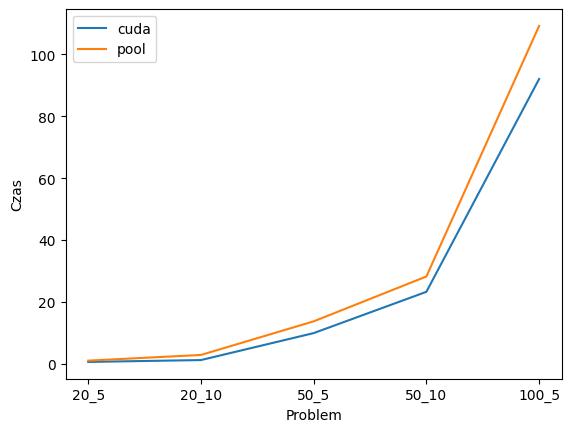

In [20]:
import time
import matplotlib.pyplot as plt

instances = ['20_5', '20_10', '50_5', '50_10', '100_5']
times_cuda = []
times_pool = []

for ins in instances:
  jobs, machines = ins.split("_")
  problem = FlowShop(jobs=int(jobs), machines=int(machines))
  problem.instance_from_file(f"/content/{ins}.txt")

  tabuCuda = TabuSearchCUDA(problem)
  tabuPool = TabuSearch(problem)
  initial_solution = tabuCuda.random_solution()

  start = time.perf_counter()
  best_solution_cuda, best_cost_cuda = tabuCuda.tabu_search(
      initial_solution=initial_solution,
      max_iterations=100,
      tabu_list_size=20,
  )
  end = time.perf_counter()
  times_cuda.append(end-start)
  print(f"Cuda: {end-start}")
  start = time.perf_counter()
  best_solution_pool, best_cost_pool = tabuPool.tabu_search(
      initial_solution=initial_solution,
      max_iterations=100,
      tabu_list_size=20,
  )
  end = time.perf_counter()
  times_pool.append(end-start)
  print(f"Pool: {end-start}")
plt.plot(instances, times_cuda, label='cuda')
plt.plot(instances, times_pool, label='pool')
plt.legend()
plt.xlabel("Problem")
plt.ylabel("Czas")

plt.show()